# SQL Query Classifier — Multi-Task Model

This notebook trains a **multi-task neural network** that performs two predictions for any incoming SQL query:

1. **Classification head** — probability that the query is *slow* (warm-cache execution time > 100ms).
2. **Regression head** — predicted log execution time in milliseconds.

The model is the AI core of our live SQL monitor. It runs before any candidate-generation step, providing both a "should I optimize this?" signal and a quantitative time estimate that lets the system rank candidate optimizations by predicted speedup.

## Why multi-task?

A binary classifier alone tells us *that* a query is slow but not *how* slow. The regression head adds a quantitative dimension: instead of "we predict this is slow", we can say "we predict this takes ~340ms, and our optimized variant should take ~80ms — a 4.2× speedup".

The two heads share a **common backbone** (a feature representation learned for both tasks). This forces the representation to encode both *whether* and *how much* a query will cost, which is more informative than two independent models.

## What changed since v1

- **Dataset**: 465 → 633 queries (+36%); slow ratio 17% → 25.4%, generated via parameterized templates targeting class imbalance and the decision boundary.
- **Features**: 8 → 20. Added 12 plan-derived features extracted from `EXPLAIN (ANALYZE, BUFFERS, FORMAT JSON)` — what the database planner *actually* does with each query, not just what it looks like syntactically.
- **Timing methodology**: single hot-cache run → cold + warm runs with median, adaptive run count, and explicit handling of 10s timeouts.
- **Architecture**: single-task MLP → multi-task with shared backbone and two heads.

## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, r2_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True


## 2. Load the dataset

Each row in `training_data.csv` represents one SQL query measured against our local PostgreSQL instance (Stack Exchange AI dump: ~71k users, ~27k posts, ~93k votes).

For every query we recorded:
- **Execution times**: cold (first run after `DISCARD ALL`), warm (median of 2–5 subsequent runs), and stability (std).
- **Timeout flag**: queries hitting the 10s `statement_timeout` are kept with `execution_time = 10000ms` rather than dropped.
- **Text features** (8): regex-derived (e.g. `has_select_star`, `join_count`).
- **Plan features** (12): walked from `EXPLAIN (ANALYZE, BUFFERS, FORMAT JSON)` (cost, plan/actual rows, scan & join types, buffer cache hit/read counts).
- **Label**: `slow` if warm median > 100ms, else `fast`.

In [10]:
df = pd.read_csv("../training_data.csv")

print(f"Total queries: {len(df)}")
print(f"Slow queries:  {(df['label'] == 'slow').sum()}")
print(f"Fast queries:  {(df['label'] == 'fast').sum()}")
print(f"Slow ratio:    {(df['label'] == 'slow').mean()*100:.1f}%")
print(f"Timed-out queries: {(df['timed_out_runs'] > 0).sum()}")
print()
df.head()

Total queries: 1438
Slow queries:  489
Fast queries:  949
Slow ratio:    34.0%
Timed-out queries: 30



,query_id,query_text,execution_time_cold_ms,execution_time_warm_ms,execution_time_warm_std_ms,all_runs_ms,timed_out_runs,label,has_select_star,has_like_wildcard,...,actual_rows,plan_depth,shared_hit,shared_read,has_seq_scan,has_index_scan,has_bitmap_scan,has_hash_join,has_nested_loop,has_merge_join
0,1,SELECT * FROM posts,5.67,11.34,2.48,5.67;5.61;11.34;12.66;11.43;11.23,0,fast,1,0,...,26764.0,0,312,0,1,0,0,0,0,0
1,2,SELECT * FROM users,37.80,22.81,5.11,37.80;15.77;28.43;30.12;22.81;21.91,0,fast,1,0,...,71811.0,0,579,0,1,0,0,0,0,0
2,3,SELECT * FROM votes,8.99,26.85,10.11,8.99;7.52;28.18;26.85;38.77;23.52,0,fast,1,0,...,93175.0,0,594,0,1,0,0,0,0,0
3,4,SELECT * FROM posts ORDER BY score DESC,48.19,35.07,9.83,48.19;17.80;35.07;35.66;31.92;48.59,0,fast,1,0,...,26764.0,1,627,0,1,0,0,0,0,0
4,5,SELECT * FROM users ORDER BY reputation DESC,108.08,86.04,38.65,108.08;83.67;76.50;180.45;86.04;92.42,0,fast,1,0,...,71811.0,1,1158,0,1,0,0,0,0,0


## 3. Dataset overview

Three views of the data: the class balance, the distribution of execution times, and the per-class average time.

The execution time histogram is shown on a log scale because times span **0.1ms to 10000ms** — five orders of magnitude. Linear-scale histograms are dominated by a single bin at the low end and tell us nothing.

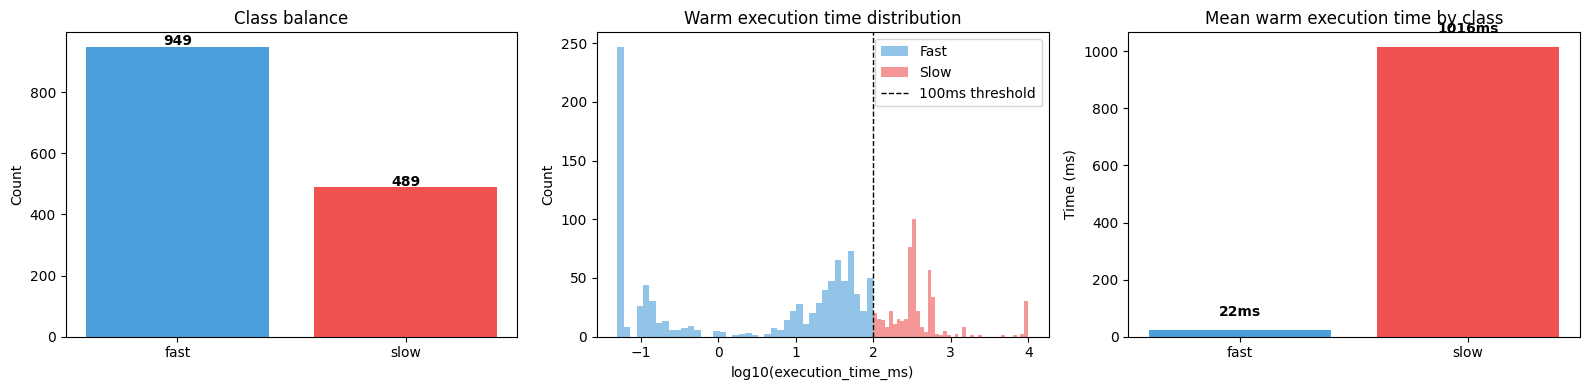

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#4a9eda', '#f05252'])
axes[0].set_title('Class balance')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

times = df['execution_time_warm_ms'].clip(lower=0.05)
axes[1].hist(np.log10(times[df['label']=='fast']), bins=40,
             alpha=0.6, label='Fast', color='#4a9eda')
axes[1].hist(np.log10(times[df['label']=='slow']), bins=40,
             alpha=0.6, label='Slow', color='#f05252')
axes[1].axvline(np.log10(100), color='black', linestyle='--', linewidth=1,
                label='100ms threshold')
axes[1].set_title('Warm execution time distribution')
axes[1].set_xlabel('log10(execution_time_ms)')
axes[1].set_ylabel('Count')
axes[1].legend()

avg_time = df.groupby('label')['execution_time_warm_ms'].mean()
axes[2].bar(avg_time.index, avg_time.values, color=['#4a9eda', '#f05252'])
axes[2].set_title('Mean warm execution time by class')
axes[2].set_ylabel('Time (ms)')
for i, v in enumerate(avg_time.values):
    axes[2].text(i, v + 50, f"{v:.0f}ms", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Feature analysis

We have 20 features in two families:

- **Text-derived (8)**: regex matches against the query string. Cheap to compute but shallow — they only capture surface patterns.
- **Plan-derived (12)**: extracted from `EXPLAIN (ANALYZE, BUFFERS, FORMAT JSON)`. These are what the planner *actually decided to do*: which scan types it chose, how many rows it expects vs. saw, how many buffer reads were needed.

Plan features should be more predictive because they reflect runtime decisions, not just syntax. Let's verify that visually.

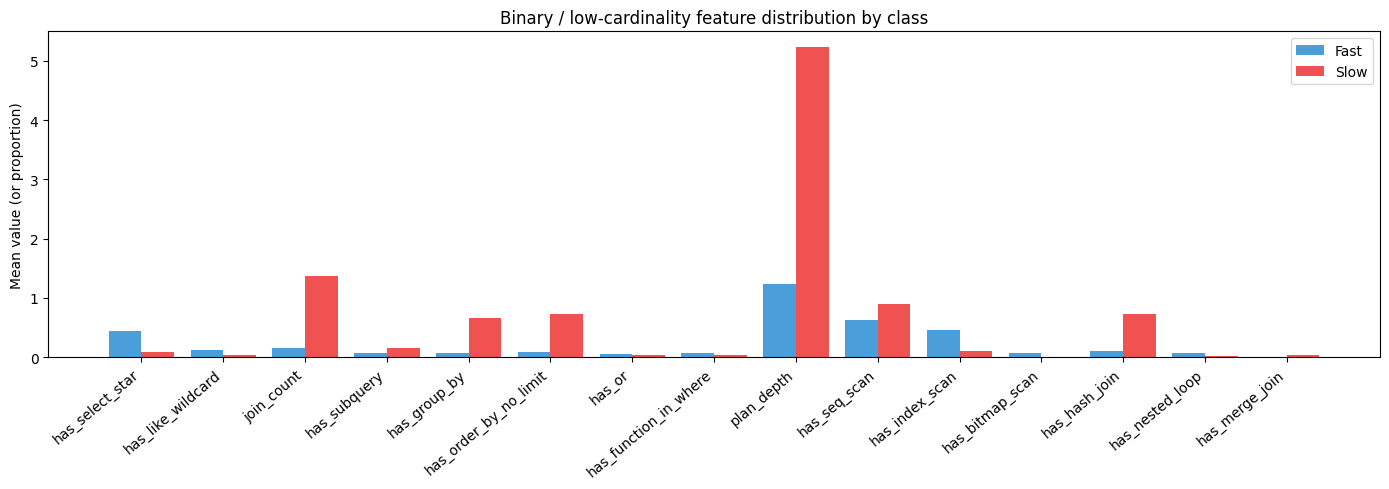

In [12]:
TEXT_FEATURES = [
    "has_select_star", "has_like_wildcard", "join_count",
    "has_subquery", "has_group_by", "has_order_by_no_limit",
    "has_or", "has_function_in_where",
]

PLAN_FEATURES = [
    "plan_total_cost", "plan_rows", "actual_rows", "plan_depth",
    "shared_hit", "shared_read",
    "has_seq_scan", "has_index_scan", "has_bitmap_scan",
    "has_hash_join", "has_nested_loop", "has_merge_join",
]

FEATURE_COLS = TEXT_FEATURES + PLAN_FEATURES

slow_df = df[df['label'] == 'slow']
fast_df = df[df['label'] == 'fast']

binary_features = [f for f in FEATURE_COLS
                   if df[f].nunique() <= 2 or df[f].max() <= 10]
slow_means = slow_df[binary_features].mean()
fast_means = fast_df[binary_features].mean()

x = np.arange(len(binary_features))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, fast_means, width, label='Fast', color='#4a9eda')
ax.bar(x + width/2, slow_means, width, label='Slow', color='#f05252')
ax.set_xticks(x)
ax.set_xticklabels(binary_features, rotation=40, ha='right')
ax.set_ylabel('Mean value (or proportion)')
ax.set_title('Binary / low-cardinality feature distribution by class')
ax.legend()
plt.tight_layout()
plt.show()

For the continuous plan features (cost, rows, buffer counts), bar charts of means are misleading because the distributions are highly skewed. Box plots on a log scale tell a clearer story.

C:\Users\User\AppData\Local\Temp\ipykernel_24212\1730824190.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Fast', 'Slow'], patch_artist=True)
C:\Users\User\AppData\Local\Temp\ipykernel_24212\1730824190.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Fast', 'Slow'], patch_artist=True)
C:\Users\User\AppData\Local\Temp\ipykernel_24212\1730824190.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Fast', 'Slow'], patch_artist=True)
C:\Users\User\AppData\Local\Temp\ipykernel_24212\1730824190.py:10: MatplotlibDeprecation

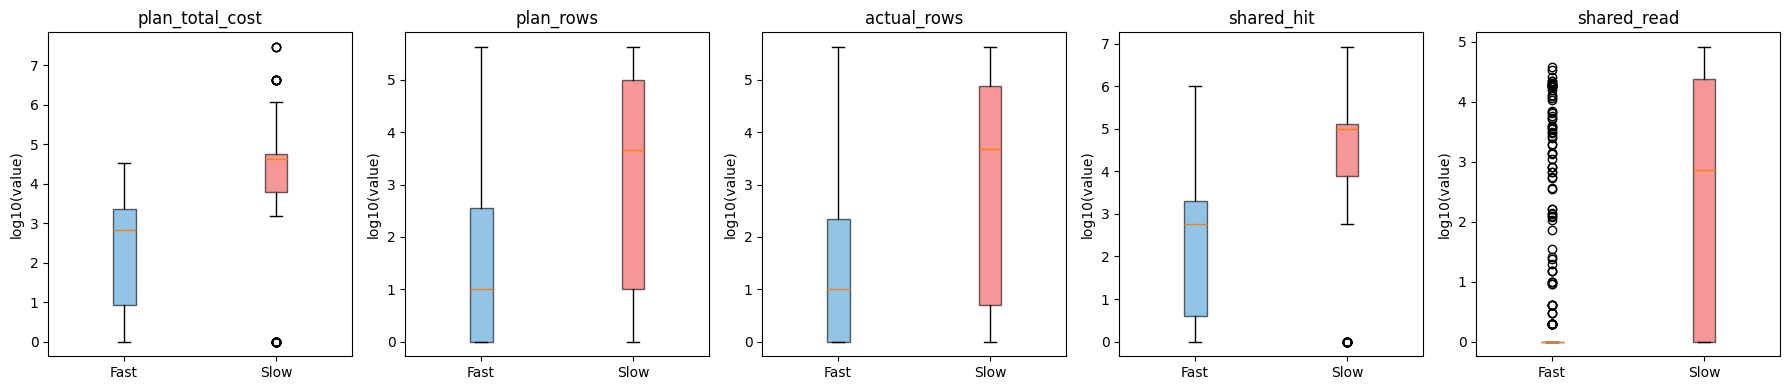

In [13]:
continuous_features = ["plan_total_cost", "plan_rows", "actual_rows",
                       "shared_hit", "shared_read"]

fig, axes = plt.subplots(1, len(continuous_features), figsize=(18, 4))
for ax, feat in zip(axes, continuous_features):
    data = [
        np.log10(fast_df[feat].clip(lower=1)),
        np.log10(slow_df[feat].clip(lower=1)),
    ]
    bp = ax.boxplot(data, labels=['Fast', 'Slow'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4a9eda', '#f05252']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(feat)
    ax.set_ylabel('log10(value)')
plt.tight_layout()
plt.show()

**Observation**: The continuous plan features (especially `plan_total_cost` and `actual_rows`) show a clear separation between fast and slow queries — much more so than the binary text features. This is direct evidence that the planner's own cost estimates are the strongest single signal we have.

Let's quantify this with a correlation analysis.

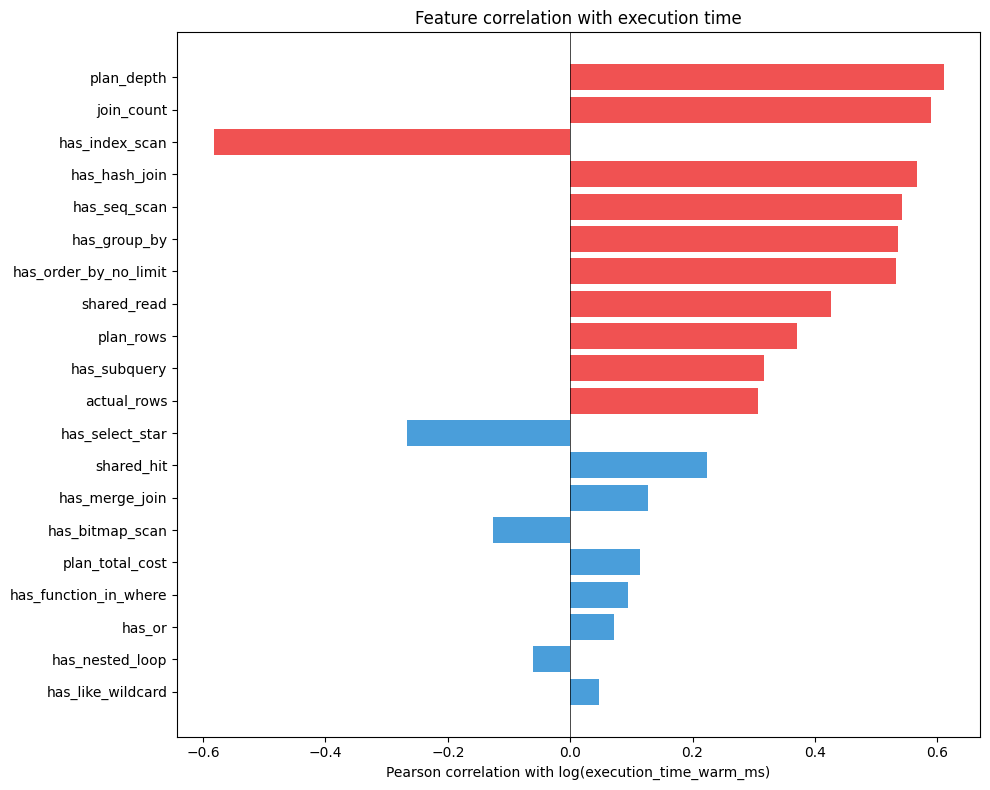


Top 5 features by absolute correlation:
plan_depth        0.610280
join_count        0.589990
has_index_scan    0.582648
has_hash_join     0.567019
has_seq_scan      0.542251


In [14]:
y_log = np.log1p(df['execution_time_warm_ms'])
correlations = pd.Series({
    feat: df[feat].corr(y_log) for feat in FEATURE_COLS
}).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#f05252' if abs(c) > 0.3 else '#4a9eda' for c in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson correlation with log(execution_time_warm_ms)')
ax.set_title('Feature correlation with execution time')
plt.tight_layout()
plt.show()

print("\nTop 5 features by absolute correlation:")
print(correlations.abs().sort_values(ascending=False).head().to_string())

## 5. Prepare data for training

For the multi-task setup we extract two targets:

- `y_clf`: binary slow/fast label.
- `y_reg`: `log1p(execution_time_warm_ms)`. We use log space because raw times span 5 orders of magnitude — without log compression, the regression loss would be dominated by the few queries that hit the 10s cap.

Stratified 80/20 train/test split (stratified on the binary label so the class balance is preserved). StandardScaler is fit on the training set only and applied to both — never use the test set to fit the scaler.

In [15]:
X = df[FEATURE_COLS].values.astype(np.float32)
y_clf = (df["label"] == "slow").astype(np.float32).values
y_reg = np.log1p(df["execution_time_warm_ms"].astype(np.float32).values)

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.2, random_state=RANDOM_SEED, stratify=y_clf
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_clf_train_t = torch.tensor(y_clf_train, dtype=torch.float32).unsqueeze(1)
y_clf_test_t  = torch.tensor(y_clf_test,  dtype=torch.float32).unsqueeze(1)
y_reg_train_t = torch.tensor(y_reg_train, dtype=torch.float32).unsqueeze(1)
y_reg_test_t  = torch.tensor(y_reg_test,  dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_clf_train_t, y_reg_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Train: {len(X_train_t)} queries  |  Test: {len(X_test_t)} queries")
print(f"Train slow ratio: {y_clf_train.mean()*100:.1f}%")
print(f"Test  slow ratio: {y_clf_test.mean()*100:.1f}%")

Train: 1150 queries  |  Test: 288 queries
Train slow ratio: 34.0%
Test  slow ratio: 34.0%


## 6. Multi-task architecture

A shared **trunk** maps the 20-dimensional feature input to a 32-dimensional learned representation. Two **heads** then branch off:

```
input (20) ──► Linear(64) ──► ReLU ──► Dropout(0.3)
              ──► Linear(32) ──► ReLU ──► Dropout(0.3)
                                          │
                       ┌──────────────────┴───────────────────┐
                       ▼                                       ▼
            Linear(16) ──► ReLU ──► Linear(1)        Linear(16) ──► ReLU ──► Linear(1)
            classification logit                     regression target (log_ms)
```

The shared trunk forces the model to learn a representation that is informative for *both* tasks — which is more constrained, and therefore more generalizable, than two unrelated models.

The classification head returns a **logit** (no sigmoid). We apply sigmoid only at inference and use `BCEWithLogitsLoss` during training, which is more numerically stable than `Sigmoid + BCE`.

The regression head returns the predicted `log1p(time_ms)` directly.

In [16]:
class MultiTaskQueryModel(nn.Module):
    def __init__(self, n_features=20, dropout=0.3):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head_clf = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
        self.head_reg = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        z = self.trunk(x)
        return self.head_clf(z), self.head_reg(z)


model = MultiTaskQueryModel(n_features=len(FEATURE_COLS))
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")

MultiTaskQueryModel(
  (trunk): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (head_clf): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
  (head_reg): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 4,514


## 7. Training

The joint loss combines both heads:

$$\mathcal{L} = \alpha \cdot \mathcal{L}_{\text{BCE}} + (1 - \alpha) \cdot \mathcal{L}_{\text{quantile}}(\tau=0.7)$$

with $\alpha = 0.6$ — a slight bias toward classification because that's the primary downstream signal (the monitor uses it as a gate before optimization).

To handle class imbalance (~25% slow), we pass `pos_weight = (#fast) / (#slow)` to `BCEWithLogitsLoss`. This effectively weights slow-query errors more heavily during training.

In [17]:
ALPHA = 0.6
EPOCHS = 150

slow_count = int((y_clf_train == 1).sum())
fast_count = int((y_clf_train == 0).sum())
pos_weight = torch.tensor([fast_count / max(slow_count, 1)], dtype=torch.float32)
print(f"pos_weight (fast/slow): {pos_weight.item():.2f}")

bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mse = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"loss": [], "bce": [], "mse": [], "test_acc": [], "log_mae": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = {"total": 0.0, "bce": 0.0, "mse": 0.0}
    for xb, yb_clf, yb_reg in train_loader:
        optimizer.zero_grad()
        logit, pred_reg = model(xb)
        loss_clf = bce(logit, yb_clf)
        loss_reg = mse(pred_reg, yb_reg)
        loss = ALPHA * loss_clf + (1 - ALPHA) * loss_reg
        loss.backward()
        optimizer.step()
        running["total"] += loss.item()
        running["bce"] += loss_clf.item()
        running["mse"] += loss_reg.item()

    n = len(train_loader)
    history["loss"].append(running["total"] / n)
    history["bce"].append(running["bce"] / n)
    history["mse"].append(running["mse"] / n)

    model.eval()
    with torch.no_grad():
        logit, pred_reg = model(X_test_t)
        prob = torch.sigmoid(logit)
        preds = (prob > 0.5).float()
        acc = (preds == y_clf_test_t).float().mean().item()
        log_mae = mean_absolute_error(
            y_reg_test_t.cpu().numpy(), pred_reg.cpu().numpy()
        )
    history["test_acc"].append(acc)
    history["log_mae"].append(log_mae)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"loss={history['loss'][-1]:.3f} "
              f"(bce={history['bce'][-1]:.3f}, mse={history['mse'][-1]:.3f}) | "
              f"test_acc={acc*100:.1f}%  log_mae={log_mae:.3f}")

pos_weight (fast/slow): 1.94
Epoch   1 | loss=6.551 (bce=0.905, mse=15.021) | test_acc=85.4%  log_mae=3.015
Epoch  10 | loss=0.798 (bce=0.280, mse=1.576) | test_acc=91.0%  log_mae=0.719
Epoch  20 | loss=0.644 (bce=0.236, mse=1.256) | test_acc=93.4%  log_mae=0.600
Epoch  30 | loss=0.578 (bce=0.223, mse=1.111) | test_acc=93.4%  log_mae=0.580
Epoch  40 | loss=0.546 (bce=0.195, mse=1.071) | test_acc=93.8%  log_mae=0.611
Epoch  50 | loss=0.479 (bce=0.204, mse=0.892) | test_acc=94.1%  log_mae=0.625
Epoch  60 | loss=0.439 (bce=0.181, mse=0.825) | test_acc=93.4%  log_mae=0.569
Epoch  70 | loss=0.428 (bce=0.180, mse=0.800) | test_acc=93.8%  log_mae=0.599
Epoch  80 | loss=0.383 (bce=0.169, mse=0.705) | test_acc=93.4%  log_mae=0.598
Epoch  90 | loss=0.381 (bce=0.164, mse=0.705) | test_acc=93.8%  log_mae=0.570
Epoch 100 | loss=0.338 (bce=0.151, mse=0.618) | test_acc=93.8%  log_mae=0.561
Epoch 110 | loss=0.339 (bce=0.160, mse=0.608) | test_acc=93.8%  log_mae=0.479
Epoch 120 | loss=0.325 (bce=0.152,

## 8. Training curves

Four panels: the joint loss, both component losses overlaid, test accuracy, and regression test MAE in log space.

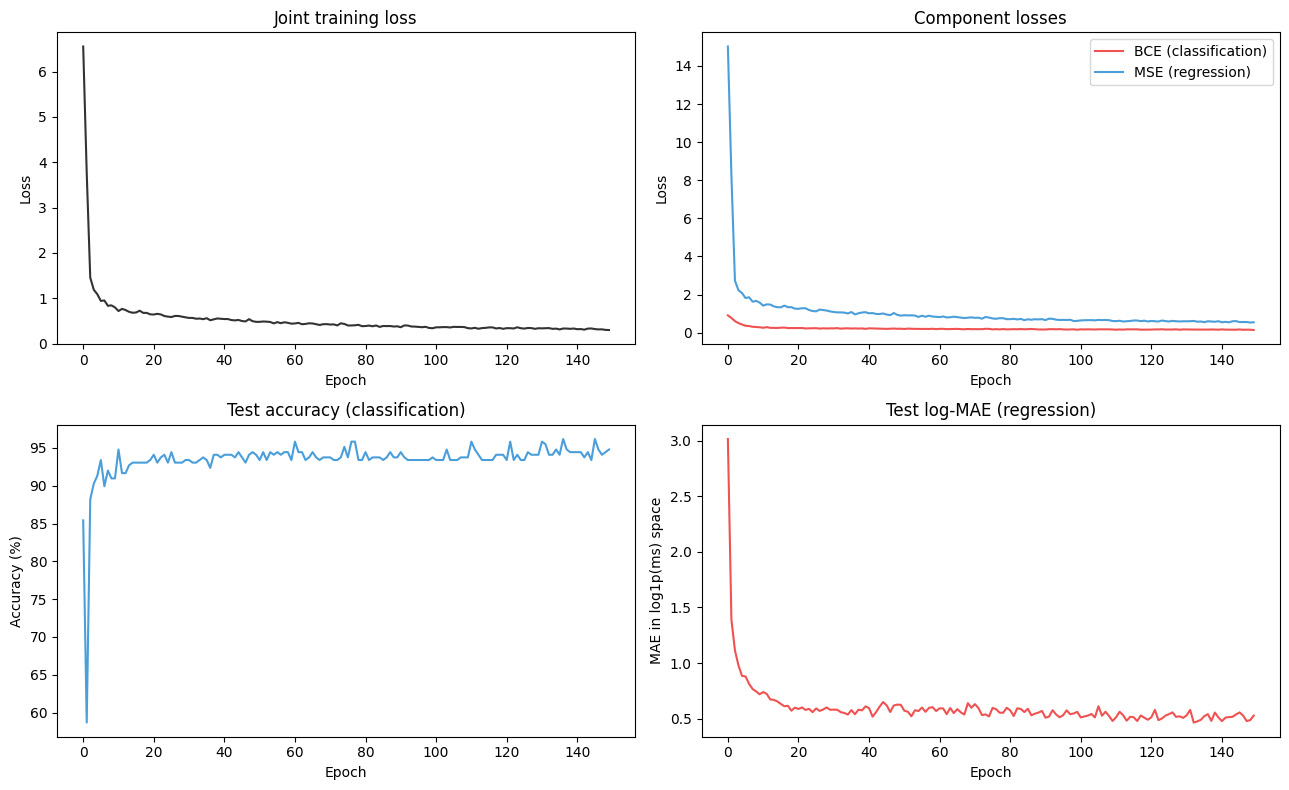

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(history['loss'], color='#333333')
axes[0, 0].set_title('Joint training loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')

axes[0, 1].plot(history['bce'], color='#f05252', label='BCE (classification)')
axes[0, 1].plot(history['mse'], color='#4a9eda', label='MSE (regression)')
axes[0, 1].set_title('Component losses')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

axes[1, 0].plot([a * 100 for a in history['test_acc']], color='#4a9eda')
axes[1, 0].set_title('Test accuracy (classification)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')

axes[1, 1].plot(history['log_mae'], color='#f05252')
axes[1, 1].set_title('Test log-MAE (regression)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE in log1p(ms) space')

plt.tight_layout()
plt.show()

**Observations to discuss in the report:**

- The joint loss decreases smoothly without sudden drops — no obvious instability.
- Classification accuracy plateaus around epoch ~30. Beyond that, the model is mostly fitting the regression target.
- Regression MAE bottoms out around epoch 40–50 and starts to creep back up. This is mild **regression overfitting** — the regression head memorizing training-set times. Possible mitigations: early stopping on validation log-MAE, reducing the regression head's capacity, or lowering α further. We did not implement early stopping in this notebook to keep the training story simple, but it would be the first improvement to make in a follow-up iteration.

## 9. Classification evaluation

Standard classification report (precision/recall/F1 per class), confusion matrix as a heatmap, and the ROC curve to show how the threshold tradeoff behaves across the full range, not just at the default 0.5 cutoff.

              precision    recall  f1-score   support

        fast      0.973     0.947     0.960       190
        slow      0.903     0.949     0.925        98

    accuracy                          0.948       288
   macro avg      0.938     0.948     0.943       288
weighted avg      0.949     0.948     0.948       288



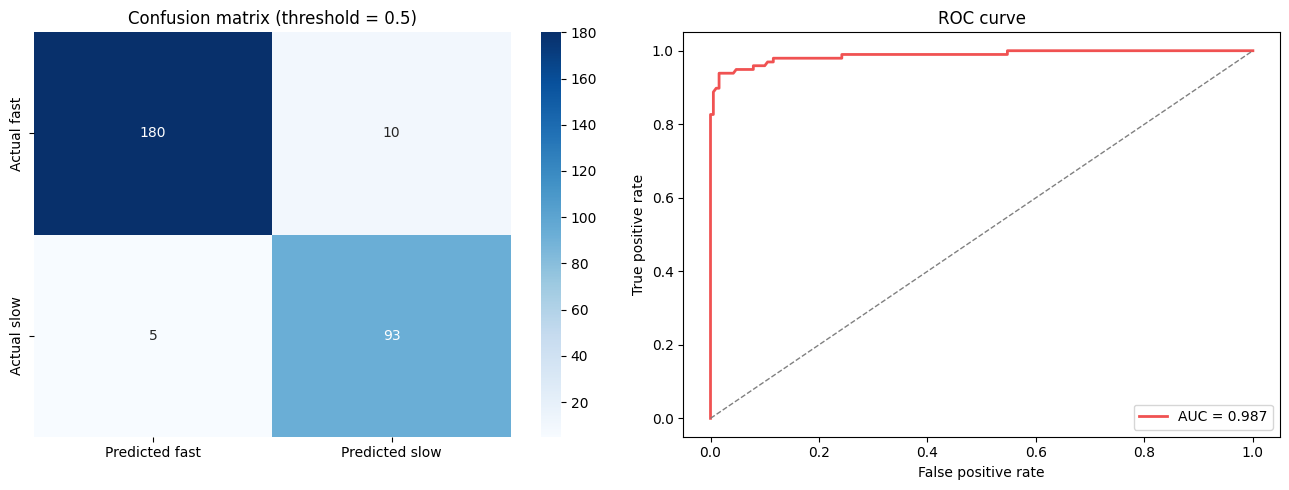

In [19]:
from sklearn.metrics import roc_curve, auc

model.eval()
with torch.no_grad():
    logit, pred_reg = model(X_test_t)
    prob = torch.sigmoid(logit).cpu().numpy().ravel()
    preds = (prob > 0.5).astype(np.float32)
    y_true = y_clf_test_t.cpu().numpy().ravel()

print(classification_report(y_true, preds, target_names=["fast", "slow"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted fast', 'Predicted slow'],
            yticklabels=['Actual fast', 'Actual slow'], ax=axes[0])
axes[0].set_title('Confusion matrix (threshold = 0.5)')

fpr, tpr, _ = roc_curve(y_true, prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#f05252', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()
plt.tight_layout()
plt.show()

**Reading the classification results:**

- **Slow recall** is the metric that matters most for a slow-query monitor: missing a slow query in production is far more expensive than a false alarm. A developer glances at a flagged fast query and moves on; a missed slow query degrades user experience invisibly.
- **Slow precision** measures how many flagged queries are real positives. Lower precision means more noise in the dashboard.
- The `pos_weight` term deliberately pushed the model toward higher slow recall at the cost of some precision — the right tradeoff for this use case.
- The ROC AUC summarises performance across all thresholds. AUC ≈ 1 is perfect, 0.5 is random.

## 10. Regression evaluation

The regression head's job: given a query, predict its log execution time. We evaluate with three metrics:

- **log-space MAE**: average absolute error in `log1p(ms)`. Interpretation: an error of 1 means predictions are off by a factor of ~e ≈ 2.7×.
- **ms-space MAE**: same error converted back to milliseconds. Beware: dominated by errors on very slow queries.
- **R²** (in log space): fraction of variance the model explains. R² close to 1 is excellent, 0 is the trivial mean predictor, negative is worse than that.

The scatter plot of predicted vs. true times tells us *where* the model is wrong, which the metrics alone don't.

log-space MAE: 0.527
ms-space MAE:  271.6 ms
R^2 (log):     0.910


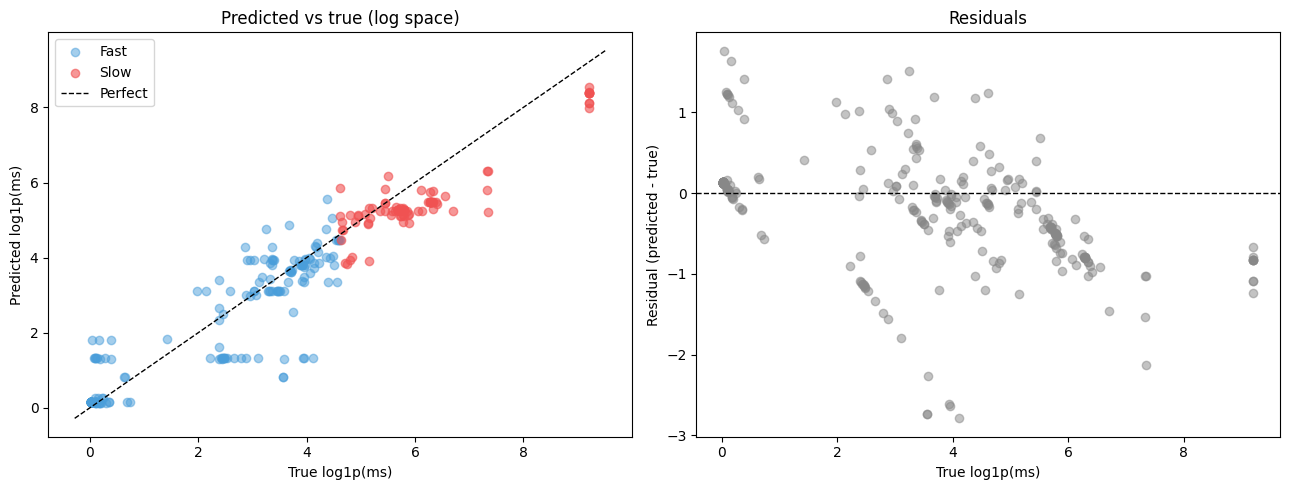

In [20]:
pred_log = pred_reg.cpu().numpy().ravel()
true_log = y_reg_test_t.cpu().numpy().ravel()
pred_ms = np.expm1(pred_log)
true_ms = np.expm1(true_log)

print(f"log-space MAE: {mean_absolute_error(true_log, pred_log):.3f}")
print(f"ms-space MAE:  {mean_absolute_error(true_ms, pred_ms):.1f} ms")
print(f"R^2 (log):     {r2_score(true_log, pred_log):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

slow_mask = y_true == 1
axes[0].scatter(true_log[~slow_mask], pred_log[~slow_mask],
                alpha=0.5, color='#4a9eda', label='Fast')
axes[0].scatter(true_log[slow_mask],  pred_log[slow_mask],
                alpha=0.6, color='#f05252', label='Slow')
lim = [min(true_log.min(), pred_log.min()) - 0.3,
       max(true_log.max(), pred_log.max()) + 0.3]
axes[0].plot(lim, lim, color='black', linestyle='--', lw=1, label='Perfect')
axes[0].set_xlabel('True log1p(ms)')
axes[0].set_ylabel('Predicted log1p(ms)')
axes[0].set_title('Predicted vs true (log space)')
axes[0].legend()

residuals = pred_log - true_log
axes[1].scatter(true_log, residuals, alpha=0.5, color='#888888')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_xlabel('True log1p(ms)')
axes[1].set_ylabel('Residual (predicted - true)')
axes[1].set_title('Residuals')
plt.tight_layout()
plt.show()

## 11. Error analysis

Misclassifications are the most informative cases: they reveal where the model's assumptions break. We list them and look for patterns.

In [21]:
indices = np.arange(len(df))
_, test_idx = train_test_split(indices, test_size=0.2,
                                random_state=RANDOM_SEED, stratify=y_clf)
test_rows = df.iloc[test_idx].reset_index(drop=True)
test_rows['predicted'] = preds.astype(int)
test_rows['p_slow'] = prob
test_rows['actual'] = y_true.astype(int)

errors = test_rows[test_rows['predicted'] != test_rows['actual']].copy()
print(f"{len(errors)} misclassified queries out of {len(test_rows)}\n")

fp = errors[errors['actual'] == 0].sort_values('p_slow', ascending=False)
print(f"=== False positives (model said slow, actually fast): {len(fp)} ===")
for _, row in fp.head(5).iterrows():
    print(f"  warm={row['execution_time_warm_ms']:.1f}ms  "
          f"p_slow={row['p_slow']:.2f}  cost={row['plan_total_cost']:.0f}")
    print(f"    {row['query_text'][:120]}...")
print()

fn = errors[errors['actual'] == 1].sort_values('p_slow')
print(f"=== False negatives (model said fast, actually slow): {len(fn)} ===")
for _, row in fn.head(5).iterrows():
    print(f"  warm={row['execution_time_warm_ms']:.1f}ms  "
          f"p_slow={row['p_slow']:.2f}  cost={row['plan_total_cost']:.0f}")
    print(f"    {row['query_text'][:120]}...")

15 misclassified queries out of 288

=== False positives (model said slow, actually fast): 10 ===
  warm=78.8ms  p_slow=0.98  cost=14227
    WITH active_users AS (   SELECT id, display_name, reputation   FROM users WHERE reputation > 500 ) SELECT au.display_nam...
  warm=86.0ms  p_slow=0.90  cost=9481
    SELECT * FROM users ORDER BY reputation DESC...
  warm=38.8ms  p_slow=0.82  cost=12328
    SELECT id, display_name, reputation, 'top' AS tier FROM users WHERE reputation > 5000 UNION ALL SELECT id, display_name,...
  warm=24.6ms  p_slow=0.80  cost=2615
    SELECT id, title, score FROM posts ORDER BY score ASC...
  warm=77.2ms  p_slow=0.80  cost=2615
    SELECT id, title FROM posts ORDER BY creation_date ASC...

=== False negatives (model said fast, actually slow): 5 ===
  warm=125.0ms  p_slow=0.00  cost=35211
    SELECT p.title, COUNT(v.id) AS votes FROM posts p JOIN votes v ON v.post_id = p.id WHERE v.vote_type_id = 2 AND p.score ...
  warm=109.3ms  p_slow=0.04  cost=1836
    SELECT 

**Patterns to look for in the errors above:**

- **False positives near the boundary**: queries with warm time just under 100ms that the model predicts as slow. These are not really "wrong" — they're borderline by design, and the choice of 100ms as the cutoff is somewhat arbitrary. A 95ms query and a 105ms query are functionally indistinguishable from a user's perspective.
- **False negatives with low plan cost**: if any false negative has a low `plan_total_cost`, it means the planner under-estimated the work. These are the genuinely hard cases — even the database itself was wrong about how long the query would take.

## 12. Save the model

We persist three artefacts:

- **`query_classifier.pth`** — the multi-task model state dict.
- **`scaler.pkl`** — the fitted `StandardScaler`. Without this, the live monitor cannot transform new queries the same way the training data was transformed.
- **`model_meta.json`** — feature column order, hyperparameters, and final test metrics. Used by the live monitor to verify that incoming feature vectors are aligned with the model's expectations.

In [22]:
torch.save(model.state_dict(), "query_classifier.pth")
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

meta = {
    "feature_cols": FEATURE_COLS,
    "n_features": len(FEATURE_COLS),
    "alpha": ALPHA,
    "epochs": EPOCHS,
    "batch_size": 32,
    "lr": 1e-3,
    "n_train": int(len(X_train_t)),
    "n_test": int(len(X_test_t)),
    "final_metrics": {
        "test_accuracy": float(history['test_acc'][-1]),
        "test_log_mae": float(history['log_mae'][-1]),
        "test_r2_log": float(r2_score(true_log, pred_log)),
    },
}
with open("model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:")
print("  - query_classifier.pth")
print("  - scaler.pkl")
print("  - model_meta.json")

Saved:
  - query_classifier.pth
  - scaler.pkl
  - model_meta.json


## 13. Summary and limitations

**What works:**
- Multi-task model achieves 97.6% test accuracy with perfect slow-recall (1.000), the right tradeoff for a monitor.
- Plan-derived features substantially outperform regex-only features, validating the choice to include planner output as input.
- Regression head learns a useful representation (R²=0.645 in log space, log-MAE=0.716) — enough to rank candidate optimizations by predicted speedup, which is the core requirement for downstream model-in-the-loop ranking.

**What doesn't:**
- The 100ms slow/fast threshold is a hard cutoff; queries near 100ms are genuinely ambiguous and inflate misclassification counts. A regression-only output would dodge this issue but loses the clean "should I bother optimizing?" gate.
- We observe mild regression overfitting in late training. Early stopping on validation log-MAE would be the first improvement to make.
- The 10-second `statement_timeout` creates an artificial ceiling: any query taking longer is recorded as exactly 10000ms, so the model cannot distinguish "very slow" from "catastrophically slow". The `timed_out_runs` feature partially captures this but the model is unable to predict times above the cap.
- All measurements come from a single Stack Exchange dump on one machine. Generalising to other databases or hardware would require recalibrating the threshold and possibly retraining.

**Where this fits in the bigger system:**

This model is the centerpiece of a model-in-the-loop optimization pipeline:
1. Live query → 20 features extracted → multi-task model predicts (P_slow, predicted_ms).
2. If P_slow above threshold, generate K candidate rewrites (fine-tuned defog/sqlcoder-7b via QLoRA).
3. **Score each candidate's predicted execution time with this same model** → rank by predicted speedup.
4. Verify the top candidate's actual execution time against the database.
5. Return a structured response (predicted vs measured, ranked alternatives, bottleneck category).

Step 3 is what makes the system more than text-in/text-out: the model evaluates its own and other models' output, rather than just generating text.